# Weather Delay Duration Prediction
This notebook trains XGBoost and LightGBM regression models to predict the duration of weather delays for flights that are already known to be weather delayed.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Data

In [2]:
df_delayed = pd.read_csv('/content/drive/MyDrive/df_delayed.csv')

# Target variable: departure delay in minutes
y = df_delayed['Departure delay (Minutes)']
X = df_delayed.drop(columns=['Departure delay (Minutes)', 'weather_delayed'])

print(f'Target variable stats:')
print(y.describe())

Target variable stats:
count    39794.000000
mean       108.987888
std        132.707032
min          1.000000
25%         37.000000
50%         70.000000
75%        133.000000
max       1804.000000
Name: Departure delay (Minutes), dtype: float64


## 3. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (31835, 46)
Test size: (7959, 46)


## 4. Clean and Preprocess Data

In [5]:
# Drop leakage and unnecessary columns
drop_cols = ["date", "origin_lat", "origin_lon", "dest_lat", "dest_lon", "Actual elapsed time (Minutes)"]
X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# Encode categorical columns with shared mapping
le = LabelEncoder()

# Carrier Code
le.fit(pd.concat([X_train['Carrier Code'], X_test['Carrier Code']]).unique())
carrier_mapping = dict(zip(le.transform(le.classes_), le.classes_))
X_train['Carrier Code'] = le.transform(X_train['Carrier Code'])
X_test['Carrier Code'] = le.transform(X_test['Carrier Code'])

# Airport codes — fit on all unique values across both train and test
all_airports = pd.Series(pd.concat([X_train['origin_code'], X_test['origin_code'],
                                     X_train['destination_code'], X_test['destination_code']]).unique())
le.fit(all_airports)
airport_mapping = dict(zip(le.transform(le.classes_), le.classes_))
X_train['origin_code'] = le.transform(X_train['origin_code'])
X_test['origin_code'] = le.transform(X_test['origin_code'])
X_train['destination_code'] = le.transform(X_train['destination_code'])
X_test['destination_code'] = le.transform(X_test['destination_code'])

print('Carrier mapping:', carrier_mapping)
print('Airport mapping:', airport_mapping)

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print(f'\nFinal train shape: {X_train.shape}')
print(f'Final test shape: {X_test.shape}')

Carrier mapping: {np.int64(0): 'AA', np.int64(1): 'DL', np.int64(2): 'UA', np.int64(3): 'WN'}
Airport mapping: {np.int64(0): 'ABQ', np.int64(1): 'AGS', np.int64(2): 'ALB', np.int64(3): 'AMA', np.int64(4): 'ANC', np.int64(5): 'ATL', np.int64(6): 'ATW', np.int64(7): 'AUS', np.int64(8): 'AVL', np.int64(9): 'AVP', np.int64(10): 'BDL', np.int64(11): 'BFL', np.int64(12): 'BGR', np.int64(13): 'BHM', np.int64(14): 'BIL', np.int64(15): 'BIS', np.int64(16): 'BLI', np.int64(17): 'BNA', np.int64(18): 'BOI', np.int64(19): 'BOS', np.int64(20): 'BQN', np.int64(21): 'BTR', np.int64(22): 'BTV', np.int64(23): 'BUF', np.int64(24): 'BUR', np.int64(25): 'BWI', np.int64(26): 'BZN', np.int64(27): 'CAE', np.int64(28): 'CHA', np.int64(29): 'CHO', np.int64(30): 'CHS', np.int64(31): 'CID', np.int64(32): 'CLE', np.int64(33): 'CLT', np.int64(34): 'CMH', np.int64(35): 'COS', np.int64(36): 'CRP', np.int64(37): 'CVG', np.int64(38): 'DAB', np.int64(39): 'DAL', np.int64(40): 'DAY', np.int64(41): 'DCA', np.int64(42): 'D

## 5. Model Training

### 5.1 XGBoost Regressor

In [6]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print(f'XGBoost Results:')
print(f'  RMSE: {xgb_rmse:.2f} minutes')
print(f'  MAE:  {xgb_mae:.2f} minutes')
print(f'  R²:   {xgb_r2:.4f}')

XGBoost Results:
  RMSE: 124.95 minutes
  MAE:  72.34 minutes
  R²:   0.1757


### 5.2 LightGBM Regressor

In [7]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_preds = lgbm_model.predict(X_test)

lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_preds))
lgbm_mae = mean_absolute_error(y_test, lgbm_preds)
lgbm_r2 = r2_score(y_test, lgbm_preds)

print(f'LightGBM Results:')
print(f'  RMSE: {lgbm_rmse:.2f} minutes')
print(f'  MAE:  {lgbm_mae:.2f} minutes')
print(f'  R²:   {lgbm_r2:.4f}')

LightGBM Results:
  RMSE: 125.94 minutes
  MAE:  72.57 minutes
  R²:   0.1626


## 6. Model Comparison

In [8]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'RMSE': [xgb_rmse, lgbm_rmse],
    'MAE': [xgb_mae, lgbm_mae],
    'R²': [xgb_r2, lgbm_r2]
})

print(results.to_string(index=False))

   Model       RMSE       MAE       R²
 XGBoost 124.946515 72.338413 0.175729
LightGBM 125.939331 72.569930 0.162578


## 7. Feature Importance

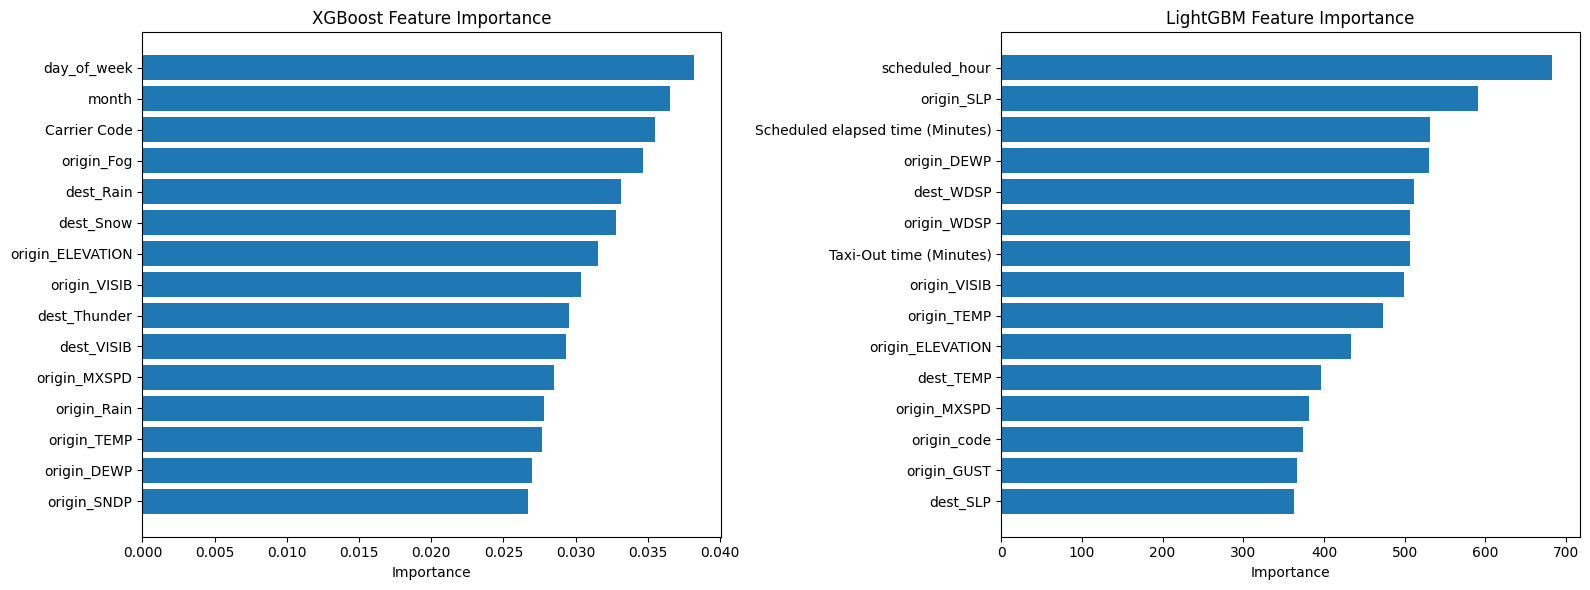

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost feature importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[0].barh(xgb_importance.index[::-1], xgb_importance.values[::-1])
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('Importance')

# LightGBM feature importance
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(lgbm_importance.index[::-1], lgbm_importance.values[::-1])
axes[1].set_title('LightGBM Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 8. Prediction vs Actual

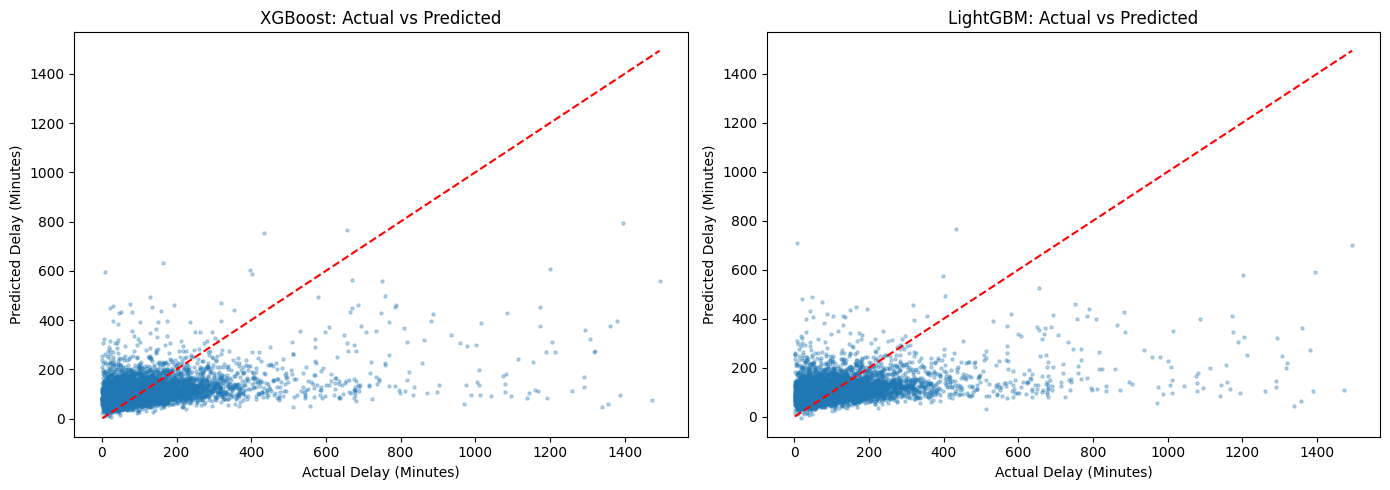

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, xgb_preds, alpha=0.3, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Delay (Minutes)')
axes[0].set_ylabel('Predicted Delay (Minutes)')
axes[0].set_title('XGBoost: Actual vs Predicted')

axes[1].scatter(y_test, lgbm_preds, alpha=0.3, s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Delay (Minutes)')
axes[1].set_ylabel('Predicted Delay (Minutes)')
axes[1].set_title('LightGBM: Actual vs Predicted')

plt.tight_layout()
plt.show()

count    39794.000000
mean       108.987888
std        132.707032
min          1.000000
25%         37.000000
50%         70.000000
75%        133.000000
max       1804.000000
Name: Departure delay (Minutes), dtype: float64
Axes(0.125,0.11;0.775x0.77)


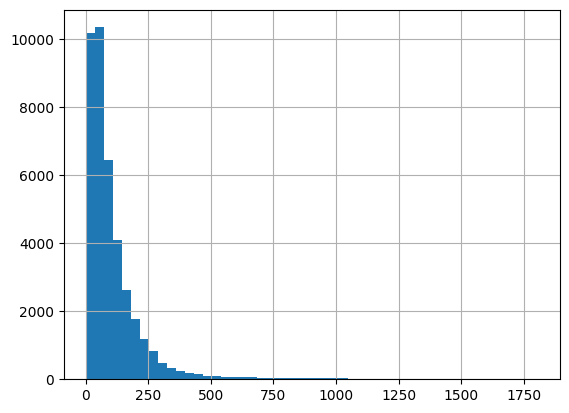

In [11]:
print(df_delayed['Departure delay (Minutes)'].describe())
print(df_delayed['Departure delay (Minutes)'].hist(bins=50))

In [12]:
print(y_test.describe())
print(xgb_preds.max())

count    7959.000000
mean      110.946601
std       137.631052
min         1.000000
25%        37.000000
50%        71.000000
75%       135.000000
max      1494.000000
Name: Departure delay (Minutes), dtype: float64
795.3257
